
# SPSID Demo on DREAM5 Network 2 (S. aureus, GRNBoost)

This notebook demonstrates how to:

1. Load an example observed network `example_W_obs.csv` (S. aureus, GRNBoost).
2. Construct the corresponding gold‑standard adjacency matrix from the DREAM5 gold standard.
3. Run **six** denoising methods:
   - `SPSID`
   - `RENDOR`
   - `ND` 
   - `NE` 
   - `Silencer`
   - `ICM` 
4. Compute **AUROC** and **AUPR** for each method.
5. Visualise the results in bar plots.


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from methods import spsid, rendor, nd_regulatory, network_enhancement, silencer, icm
from utils_dream5 import load_gold_standard_edges, create_combined_matrix_from_df

# Use repo root as base
BASE_DIR = os.getcwd()

# Paths
EXAMPLE_PATH = os.path.join(BASE_DIR, "data", "dream5", "GRN_Network", "example_W_obs.csv")
GS_PATH = os.path.join(
    BASE_DIR,
    "data", "dream5", "Gold_Standard",
    "DREAM5_NetworkInference_GoldStandard_Network2 - S. aureus.txt"
)

print("BASE_DIR      :", BASE_DIR)
print("EXAMPLE_PATH  :", EXAMPLE_PATH)
print("GS_PATH       :", GS_PATH)


BASE_DIR      : e:\PHD\Project\2025\sTRAND\Submissioin\Revision\Github\SPSID
EXAMPLE_PATH  : e:\PHD\Project\2025\sTRAND\Submissioin\Revision\Github\SPSID\data\dream5\GRN_Network\example_W_obs.csv
GS_PATH       : e:\PHD\Project\2025\sTRAND\Submissioin\Revision\Github\SPSID\data\dream5\Gold_Standard\DREAM5_NetworkInference_GoldStandard_Network2 - S. aureus.txt


In [20]:
# ---------------------------
# 1. Load observed network
# ---------------------------
if not os.path.exists(EXAMPLE_PATH):
    raise FileNotFoundError(f"example_W_obs.csv not found at: {EXAMPLE_PATH}")

# Many users will save a matrix with row/column labels (gene names).
# We therefore read with index_col=0 so that the first column is treated as index.
df_obs = pd.read_csv(EXAMPLE_PATH, index_col=0)

# Ensure all entries are numeric; any non-numeric cells are coerced to NaN then filled with 0.
df_obs_numeric = df_obs.apply(pd.to_numeric, errors="coerce").fillna(0.0)

W_obs = df_obs_numeric.values.astype(float)
print("Loaded W_obs with shape:", W_obs.shape)


Loaded W_obs with shape: (484, 484)


In [21]:
# ----------------------------------------------
# 2. Load gold standard
# ----------------------------------------------
if not os.path.exists(GS_PATH):
    raise FileNotFoundError(f"Gold standard file not found: {GS_PATH}")

true_edges_df, gs_tfs, gs_targets = load_gold_standard_edges(GS_PATH)
if true_edges_df is None:
    raise RuntimeError("Failed to load gold standard edges.")

M_true = create_combined_matrix_from_df(
    gs_tfs,
    gs_targets,
    true_edges_df,
    is_binary_truth=True
)

print("Gold standard M_true shape:", M_true.shape)

if M_true.shape != W_obs.shape:
    raise ValueError(
        f"Shape mismatch between W_obs {W_obs.shape} and M_true {M_true.shape}. "
        "Please ensure example_W_obs.csv was generated from the same gold standard."
    )

y_true_flat = M_true.flatten().astype(int)
print("Number of positives in gold standard:", y_true_flat.sum())
print("Total edges:", y_true_flat.size)
print("Positive class ratio:", y_true_flat.mean())


  Gold Standard: Loaded 38 TFs and 446 Target Genes.
Gold standard M_true shape: (484, 484)
Number of positives in gold standard: 1030
Total edges: 234256
Positive class ratio: 0.004396899118912643


In [22]:
# -------------------------------------
# 3. Run six denoising methods on W_obs
# -------------------------------------

def eval_scores(y_true, y_score, label):
    # Utility to compute AUROC and AUPR
    auroc = roc_auc_score(y_true, y_score)
    aupr = average_precision_score(y_true, y_score)
    print(f"{label:10s}  AUROC = {auroc:.4f},  AUPR = {aupr:.4f}")
    return auroc, aupr

results = []

# 1) SPSID
G_spsid = spsid(W_obs.copy(), eps1=1e-6, eps2=1e-6, lambda_val=1000, return_tf_only=True)
auroc, aupr = eval_scores(y_true_flat, G_spsid.flatten(), "SPSID")
results.append({"Method": "SPSID", "AUROC": auroc, "AUPR": aupr})

# 2) RENDOR
G_rendor = rendor(W_obs.copy(), m=2)
auroc, aupr = eval_scores(y_true_flat, G_rendor.flatten(), "RENDOR")
results.append({"Method": "RENDOR", "AUROC": auroc, "AUPR": aupr})

# 3) ND
G_nd = nd_regulatory(W_obs.copy(), beta=0.5, alpha=1.0)
auroc, aupr = eval_scores(y_true_flat, G_nd.real.flatten(), "ND")
results.append({"Method": "ND", "AUROC": auroc, "AUPR": aupr})

# 4) NE
G_ne = network_enhancement(W_obs.copy(), order=2, K=20, alpha=0.9)
auroc, aupr = eval_scores(y_true_flat, G_ne.flatten(), "NE")
results.append({"Method": "NE", "AUROC": auroc, "AUPR": aupr})

# 5) Silencer
G_sil = silencer(W_obs.copy())
auroc, aupr = eval_scores(y_true_flat, G_sil.flatten(), "Silencer")
results.append({"Method": "Silencer", "AUROC": auroc, "AUPR": aupr})

# 6) ICM
G_icm = icm(W_obs.copy(), lambda_icm=1e-2)
auroc, aupr = eval_scores(y_true_flat, G_icm.flatten(), "ICM")
results.append({"Method": "ICM", "AUROC": auroc, "AUPR": aupr})

df_results = pd.DataFrame(results)
df_results


SPSID       AUROC = 0.9477,  AUPR = 0.0752
RENDOR      AUROC = 0.8031,  AUPR = 0.0373
ND          AUROC = 0.8324,  AUPR = 0.0665
NE          AUROC = 0.8025,  AUPR = 0.0566
Silencer    AUROC = 0.5264,  AUPR = 0.0045
ICM         AUROC = 0.4947,  AUPR = 0.0148


,Method,AUROC,AUPR
0,SPSID,0.947717,0.075224
1,RENDOR,0.803112,0.037264
2,ND,0.832390,0.066543
3,NE,0.802493,0.056560
4,Silencer,0.526363,0.004508
5,ICM,0.494656,0.014780


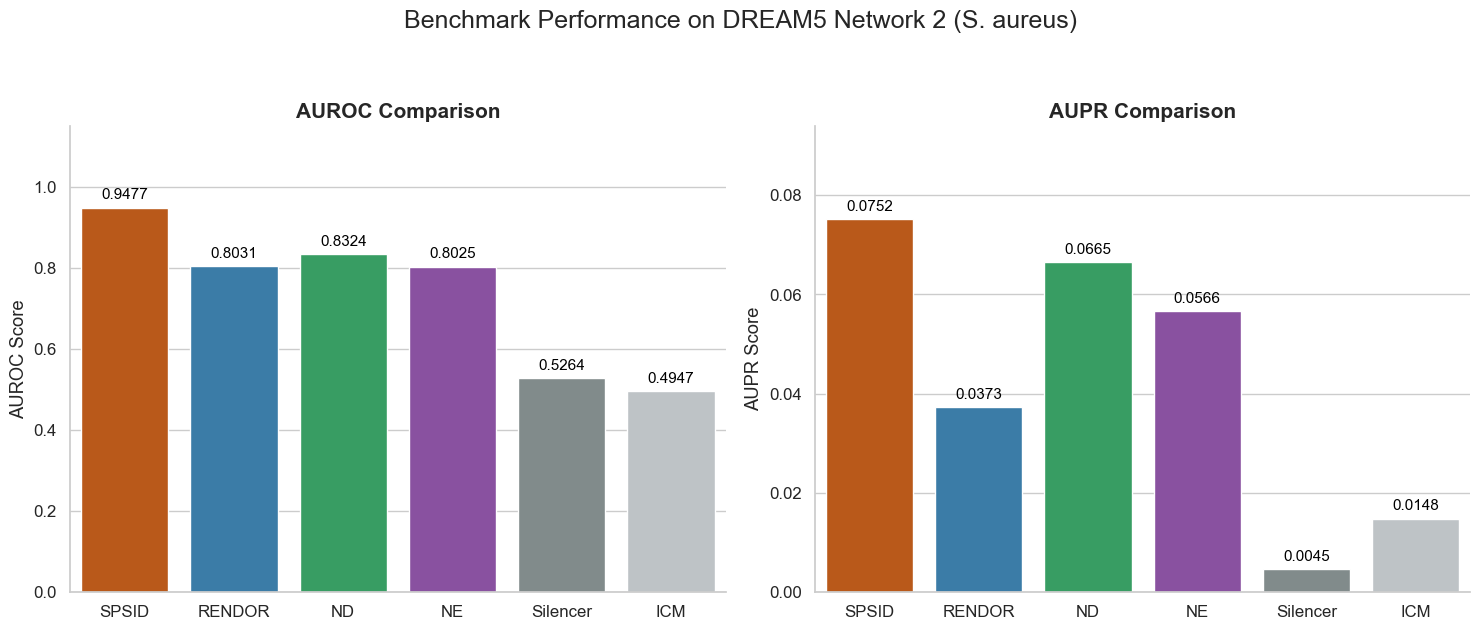

In [23]:
# ------------------------------
# 4. Visualise AUROC & AUPR
# ------------------------------

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
custom_palette = {
    "SPSID": "#d35400",        
    "SPSID Output": "#d35400", 
    "RENDOR": "#2980b9",       
    "ND": "#27ae60",          
    "NE": "#8e44ad",        
    "Silencer": "#7f8c8d",    
    "ICM": "#bdc3c7"        
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.4f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=11, color='black', xytext=(0, 4), 
                    textcoords='offset points')
    sns.despine(ax=ax)

# =================== AUROC ===================
sns.barplot(data=df_results, x="Method", y="AUROC", hue="Method", legend=False,  ax=axes[0], palette=custom_palette)

axes[0].set_title("AUROC Comparison", fontsize=15, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("AUROC Score")
axes[0].set_ylim(0, 1.15)  
add_labels(axes[0])

# =================== AUPR ===================
sns.barplot(data=df_results, x="Method", y="AUPR",  hue="Method", legend=False, ax=axes[1], palette=custom_palette)

axes[1].set_title("AUPR Comparison", fontsize=15, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("AUPR Score") 

max_aupr = df_results["AUPR"].max()
axes[1].set_ylim(0, max_aupr * 1.25) 
add_labels(axes[1])

plt.suptitle("Benchmark Performance on DREAM5 Network 2 (S. aureus)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------
# 5. Save denoised networks as CSV files
# ------------------------------

example_path = os.path.join("data", "dream5", "GRN_Network", "example_W_obs.csv")
df_obs = pd.read_csv(example_path, index_col=0)
gene_names = df_obs.index.tolist()
W_obs = df_obs.values.astype(float)
print("W_obs shape:", W_obs.shape)
print("First 5 gene names:", gene_names[:5])

denoised_mats = {
    "SPSID":    G_spsid,
    "RENDOR":   G_rendor,
    "ND":       G_nd,
    "NE":       G_ne,
    "Silencer": G_sil,
    "ICM":      G_icm,
}

out_dir = os.path.join("data", "dream5", "GRN_Network")
os.makedirs(out_dir, exist_ok=True)

for method_name, mat in denoised_mats.items():
    df_den = pd.DataFrame(mat, index=gene_names, columns=gene_names)
    out_path = os.path.join(out_dir, f"example_W_obs_{method_name}.csv")
    df_den.to_csv(out_path)
    print(f"{method_name:8s} denoised network saved to:")
    print("   ", out_path, "  Shape:", df_den.shape)




W_obs shape: (484, 484)
First 5 gene names: ['G12', 'G126', 'G1386', 'G1426', 'G1603']
SPSID    denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_SPSID.csv   Shape: (484, 484)
RENDOR   denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_RENDOR.csv   Shape: (484, 484)
ND       denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_ND.csv   Shape: (484, 484)
NE       denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_NE.csv   Shape: (484, 484)
Silencer denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_Silencer.csv   Shape: (484, 484)
ICM      denoised network saved to:
    data\dream5\GRN_Network\example_W_obs_ICM.csv   Shape: (484, 484)
